# Pipeline ordenado para papers académicos: PDF → páginas → figuras/tablas/texto → OCR

Este notebook está pensado para ejecutarse **en local**, desde **Visual Studio Code** y dentro de un **entorno virtual (`venv`)**.

## Qué hace
1. Convierte un PDF académico a imágenes por página.
2. Detecta regiones de **layout** con `PaddleOCR LayoutDetection`.
3. Refina la detección de **tablas** con **Table Transformer (TATR)**.
4. Extrae y guarda por separado:
   - páginas renderizadas
   - páginas preprocesadas
   - **figuras/imágenes**
   - **tablas**
   - **bloques de texto**
   - resultados OCR en `json` y `txt`
   - visualizaciones de depuración
5. Genera `CSV` y `JSONL` con el inventario completo de regiones.

## Idea de diseño
La intención es dejar un notebook **más limpio y reutilizable** que el flujo actual, manteniendo carpetas de salida separadas para que luego puedan ser consumidas por el proyecto grande.

## Requisitos sugeridos del entorno

Ejecuta esto en tu `venv` antes de usar el notebook.

```bash
python -m pip install --upgrade pip wheel
python -m pip install paddlepaddle paddleocr
python -m pip install torch torchvision transformers
python -m pip install pdf2image pillow opencv-python matplotlib pandas numpy tqdm
```

### Dependencias del sistema
- **Poppler** para `pdf2image`.
- Si trabajas en **Windows**, deja configurado `poppler_path` en la sección de configuración.

### Notas de modelos
- `PaddleOCR LayoutDetection` acepta imágenes, PDFs y arreglos `numpy`, y devuelve cajas con `label`, `score` y `coordinate=[xmin, ymin, xmax, ymax]`.
- En la documentación actual de PaddleOCR 3.x aparecen modelos de layout como `PP-DocLayout-L`, `PP-DocLayout-M`, `PP-DocLayout-S` y también modelos más ligeros para documentos en inglés como `PicoDet_layout_1x`, que detecta `Text`, `Title`, `Table`, `Image` y `List`.
- `microsoft/table-transformer-detection` se usa para **table detection** sobre imágenes de página. 

In [1]:
# Configuración ANTES de cualquier import
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

# Ahora los imports
import sys
import json
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Tuple

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from PIL import Image
from pdf2image import convert_from_path
from tqdm.auto import tqdm

from paddleocr import PaddleOCR, PPStructure
from transformers import DetrImageProcessor, TableTransformerForObjectDetection

c:\Users\user\proyectos\vision-docs\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

# Ayuda para entornos Windows + venv en VS Code
# Evita errores frecuentes de DLL al cargar torch.
venv_root = Path(sys.executable).resolve().parents[1]
for dll_dir in [
    venv_root / "Scripts",
    venv_root / "Lib" / "site-packages" / "torch" / "lib",
]:
    if dll_dir.exists():
        try:
            os.add_dll_directory(str(dll_dir))
        except Exception:
            pass

print("Python:", sys.version.split()[0])
print("Torch:", torch.__version__)
print("Ejecutable:", sys.executable)

Python: 3.11.9
Torch: 2.3.1+cpu
Ejecutable: c:\Users\user\proyectos\vision-docs\.venv\Scripts\python.exe


In [3]:

def find_project_root(start: Optional[Path] = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for base in [start, *start.parents]:
        markers = [
            ("data", "notebooks"),
            ("src", "data"),
            ("pyproject.toml",),
            ("requirements.txt",),
        ]
        if any(all((base / m).exists() for m in group) for group in markers):
            return base
    return start

PROJECT_ROOT = find_project_root()

CONFIG = {
    # Entrada
    "project_root": PROJECT_ROOT,
    "pdf_path": "data/raw/sample.pdf",
    "poppler_path": None,  # Ejemplo Windows: r"C:/poppler/Library/bin"

    # Render de PDF
    "dpi": 220,

    # Dispositivo
    "device": "cpu",

    # Modelos
    # Recomendado para papers en inglés y flujo práctico en local:
    # detecta Text / Title / Table / Image / List.
    "layout_model_name": "PicoDet_layout_1x",
    # Alternativa más pesada y más rica en clases:
    # "layout_model_name": "PP-DocLayout-L",

    "layout_threshold": 0.35,
    "tatr_model_name": "microsoft/table-transformer-detection",
    "tatr_threshold": 0.80,

    # OCR
    "ocr_lang": "es",
    "ocr_use_angle_cls": True,
    "ocr_min_score": 0.50,

    # Fusión
    "iou_table_priority": 0.20,     # si TATR y layout se solapan, gana TATR para tablas
    "iou_drop_figure_if_table": 0.25,

    # Preproceso suave
    "use_preprocessing": True,
    "clahe_clip_limit": 2.0,
    "clahe_grid_size": (8, 8),

    # Salidas
    "run_name": "paper_run_001",
}

OUTPUT_DIRS = {
    "root": "data/outputs/{run_name}",
    "page_images": "data/outputs/{run_name}/01_page_images",
    "preprocessed_pages": "data/outputs/{run_name}/02_preprocessed_pages",
    "layout_json": "data/outputs/{run_name}/03_layout_json",
    "layout_viz": "data/outputs/{run_name}/04_layout_viz",
    "tables": "data/outputs/{run_name}/05_tables",
    "figures": "data/outputs/{run_name}/06_figures",
    "text_blocks": "data/outputs/{run_name}/07_text_blocks",
    "ocr_json": "data/outputs/{run_name}/08_ocr_json",
    "ocr_txt": "data/outputs/{run_name}/09_ocr_txt",
    "debug_pages": "data/outputs/{run_name}/10_debug_pages",
    "manifests": "data/outputs/{run_name}/11_manifests",
}

In [4]:

def resolve_path(path_like: str | Path) -> Path:
    path = Path(path_like)
    if path.is_absolute():
        return path
    return (Path(CONFIG["project_root"]) / path).resolve()

def resolved_output_dirs() -> Dict[str, Path]:
    run_name = CONFIG["run_name"]
    return {k: resolve_path(v.format(run_name=run_name)) for k, v in OUTPUT_DIRS.items()}

def ensure_output_dirs() -> Dict[str, Path]:
    dirs = resolved_output_dirs()
    for path in dirs.values():
        path.mkdir(parents=True, exist_ok=True)
    return dirs

OUT = ensure_output_dirs()
PDF_PATH = resolve_path(CONFIG["pdf_path"])

print("PROJECT_ROOT:", PROJECT_ROOT)
print("PDF_PATH:", PDF_PATH)
print("Existe PDF:", PDF_PATH.exists())
print("OUTPUT_ROOT:", OUT["root"])

PROJECT_ROOT: C:\Users\user\proyectos\vision-docs
PDF_PATH: C:\Users\user\proyectos\vision-docs\data\raw\sample.pdf
Existe PDF: True
OUTPUT_ROOT: C:\Users\user\proyectos\vision-docs\data\outputs\paper_run_001


## Estructura de salida

Cada ejecución deja un árbol como este:

```text
data/outputs/<run_name>/
├── 01_page_images/
├── 02_preprocessed_pages/
├── 03_layout_json/
├── 04_layout_viz/
├── 05_tables/
├── 06_figures/
├── 07_text_blocks/
├── 08_ocr_json/
├── 09_ocr_txt/
├── 10_debug_pages/
└── 11_manifests/
```

Así las extracciones quedan listas para ser consumidas después por otros notebooks, scripts o pipelines.

In [5]:

@dataclass
class Region:
    page_num: int
    kind: str
    bbox: Tuple[int, int, int, int]
    score: float = 1.0
    source: str = "unknown"
    meta: Optional[Dict[str, Any]] = None

    @property
    def x1(self) -> int:
        return self.bbox[0]

    @property
    def y1(self) -> int:
        return self.bbox[1]

    @property
    def x2(self) -> int:
        return self.bbox[2]

    @property
    def y2(self) -> int:
        return self.bbox[3]

    @property
    def width(self) -> int:
        return self.x2 - self.x1

    @property
    def height(self) -> int:
        return self.y2 - self.y1

    def to_dict(self) -> Dict[str, Any]:
        return asdict(self)

    @property
    def width(self) -> int:
        return max(0, self.x2 - self.x1)

    @property
    def height(self) -> int:
        return max(0, self.y2 - self.y1)

    @property
    def area(self) -> int:
        return self.width * self.height

def clamp_box(box: Iterable[float], w: int, h: int, pad: int = 0) -> Tuple[int, int, int, int]:
    x1, y1, x2, y2 = box
    x1 = max(0, int(round(x1)) - pad)
    y1 = max(0, int(round(y1)) - pad)
    x2 = min(w, int(round(x2)) + pad)
    y2 = min(h, int(round(y2)) + pad)
    return x1, y1, x2, y2

def rgb_to_bgr(img_rgb: np.ndarray) -> np.ndarray:
    return cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)

def bgr_to_rgb(img_bgr: np.ndarray) -> np.ndarray:
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

def save_bgr(path: Path, img_bgr: np.ndarray) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(path), img_bgr)

def crop_image(img_bgr: np.ndarray, box: Tuple[int, int, int, int]) -> np.ndarray:
    x1, y1, x2, y2 = box
    return img_bgr[y1:y2, x1:x2].copy()

def compute_iou(box_a: Tuple[int, int, int, int], box_b: Tuple[int, int, int, int]) -> float:
    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b

    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)

    iw = max(0, ix2 - ix1)
    ih = max(0, iy2 - iy1)
    inter = iw * ih

    area_a = max(0, ax2 - ax1) * max(0, ay2 - ay1)
    area_b = max(0, bx2 - bx1) * max(0, by2 - by1)

    union = area_a + area_b - inter
    return inter / union if union > 0 else 0.0

In [6]:

def preprocess_page(page_bgr: np.ndarray) -> np.ndarray:
    if not CONFIG["use_preprocessing"]:
        return page_bgr.copy()

    lab = cv2.cvtColor(page_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(
        clipLimit=CONFIG["clahe_clip_limit"],
        tileGridSize=CONFIG["clahe_grid_size"],
    )
    l2 = clahe.apply(l)
    merged = cv2.merge([l2, a, b])
    return cv2.cvtColor(merged, cv2.COLOR_LAB2BGR)

def pdf_to_images(pdf_path: Path, dpi: int, poppler_path: Optional[str]) -> List[np.ndarray]:
    pages = convert_from_path(
        str(pdf_path),
        dpi=dpi,
        poppler_path=poppler_path,
    )
    out = []
    for idx, pil_img in enumerate(pages, start=1):
        rgb = np.array(pil_img.convert("RGB"))
        bgr = rgb_to_bgr(rgb)
        save_bgr(OUT["page_images"] / f"page_{idx:03d}.png", bgr)
        out.append(bgr)
    return out

In [7]:
def load_models() -> Dict[str, Any]:
    # Solo layout. Sin tablas ni OCR interno de PPStructure
    layout_engine = PPStructure(
        table=False,
        ocr=False,
        show_log=False,
    )

    # OCR puro para texto
    ocr_engine = PaddleOCR(
        use_angle_cls=CONFIG["ocr_use_angle_cls"],
        lang=CONFIG["ocr_lang"],
        show_log=False,
        use_gpu=False,   # recomendable en Windows/local para depurar
    )

    # TATR para tablas
    table_processor = DetrImageProcessor.from_pretrained(CONFIG["tatr_model_name"])
    table_model = TableTransformerForObjectDetection.from_pretrained(CONFIG["tatr_model_name"])
    table_model.eval()

    return {
        "layout_engine": layout_engine,
        "ocr_engine": ocr_engine,
        "table_processor": table_processor,
        "table_model": table_model,
    }

MODELS = load_models()
print("Modelos cargados correctamente.")

The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.
Some weights of the model checkpoint at microsoft/table-transformer-detection were not used when initializing TableTransformerForObjectDetection: ['model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing TableTransformerForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TableTransformerForObjectDetection from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification mo

Modelos cargados correctamente.


## Nota sobre la elección del layout model

Para un flujo local, `PicoDet_layout_1x` suele ser una buena base en papers en inglés porque detecta directamente `Text`, `Title`, `Table`, `Image` y `List`. PaddleOCR también documenta modelos más pesados y más ricos en clases, como `PP-DocLayout-L`, si luego quieres subir precisión o capturar más tipos de región. citeturn192472view1

In [8]:

def _layout_result_to_dict(res: Any) -> Dict[str, Any]:
    # Intenta convertir la salida de PaddleOCR a un dict uniforme.
    if isinstance(res, dict):
        return res

    if hasattr(res, "json"):
        value = res.json
        if isinstance(value, dict):
            return value
        if callable(value):
            out = value()
            if isinstance(out, dict):
                return out
            if isinstance(out, str):
                return json.loads(out)

    if hasattr(res, "to_json") and callable(res.to_json):
        maybe = res.to_json()
        if isinstance(maybe, str):
            return json.loads(maybe)
        if isinstance(maybe, dict):
            return maybe

    if hasattr(res, "res"):
        return {"res": res.res}

    raise TypeError(f"No se pudo convertir la salida de layout a dict. Tipo: {type(res)}")


def detect_layout_regions(page_bgr: np.ndarray, page_num: int) -> List[Region]:
    h, w = page_bgr.shape[:2]

    result = MODELS["layout_engine"](page_bgr)

    if not result:
        return []

    regions: List[Region] = []

    for item in result:
        region_type = item.get("type", "unknown")
        bbox = item.get("bbox", None)

        if bbox is None or len(bbox) != 4:
            continue

        x1, y1, x2, y2 = map(int, bbox)

        x1 = max(0, min(x1, w - 1))
        y1 = max(0, min(y1, h - 1))
        x2 = max(0, min(x2, w))
        y2 = max(0, min(y2, h))

        if x2 <= x1 or y2 <= y1:
            continue

        regions.append(
            Region(
                page_num=page_num,
                kind=region_type,
                bbox=(x1, y1, x2, y2),
                score=float(item.get("score", 1.0)),
                source="ppstructure",
            )
        )

    return regions

In [9]:

def detect_tables_tatr(page_bgr: np.ndarray, page_num: int) -> List[Region]:
    rgb = Image.fromarray(bgr_to_rgb(page_bgr))
    inputs = MODELS["table_processor"](images=rgb, return_tensors="pt")

    with torch.no_grad():
        outputs = MODELS["table_model"](**inputs)

    target_sizes = torch.tensor([rgb.size[::-1]])  # (height, width)
    results = MODELS["table_processor"].post_process_object_detection(
        outputs,
        threshold=CONFIG["tatr_threshold"],
        target_sizes=target_sizes,
    )[0]

    h, w = page_bgr.shape[:2]
    regions: List[Region] = []
    for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
        x1, y1, x2, y2 = clamp_box(box.tolist(), w, h)
        regions.append(
    Region(
        page_num=page_num,
        kind="table",
        bbox=(x1, y1, x2, y2),
        score=float(score.item()),
        source="tatr",
        meta={"label": int(label.item())},
    )
)
    return regions

In [10]:

def ocr_on_crop(crop_bgr: np.ndarray) -> Tuple[str, List[Dict[str, Any]]]:
    if crop_bgr.size == 0:
        return "", []

    result = MODELS["ocr_engine"].ocr(bgr_to_rgb(crop_bgr), cls=CONFIG["ocr_use_angle_cls"])
    if not result or not result[0]:
        return "", []

    lines = []
    texts = []
    for line in result[0]:
        box, (txt, score) = line
        score = float(score)
        if score >= CONFIG["ocr_min_score"]:
            lines.append({"box": box, "text": txt, "score": score})
            texts.append(txt)

    return "\n".join(texts).strip(), lines

In [11]:

def fuse_regions(layout_regions: List[Region], tatr_regions: List[Region]) -> Dict[str, List[Region]]:
    final_tables: List[Region] = []
    final_figures: List[Region] = []
    final_texts: List[Region] = []

    # 1) Tablas finales: priorizar TATR
    final_tables.extend(tatr_regions)

    # 2) Agregar tablas de layout solo si no se pisan con TATR
    for reg in layout_regions:
        if reg.kind != "table":
            continue
        reg_box = (reg.x1, reg.y1, reg.x2, reg.y2)
        overlap = any(
            compute_iou(reg_box, (tb.x1, tb.y1, tb.x2, tb.y2)) >= CONFIG["iou_table_priority"]
            for tb in tatr_regions
        )
        if not overlap:
            final_tables.append(reg)

    # 3) Figuras: eliminar si se pisan con tablas finales
    for reg in layout_regions:
        if reg.kind != "figure":
            continue
        reg_box = (reg.x1, reg.y1, reg.x2, reg.y2)
        overlap_with_table = any(
            compute_iou(reg_box, (tb.x1, tb.y1, tb.x2, tb.y2)) >= CONFIG["iou_drop_figure_if_table"]
            for tb in final_tables
        )
        if not overlap_with_table:
            final_figures.append(reg)

    # 4) Texto desde layout
    final_texts = [reg for reg in layout_regions if reg.kind == "text"]

    return {
        "tables": final_tables,
        "figures": final_figures,
        "texts": final_texts,
    }

In [12]:

def annotate_page(page_bgr: np.ndarray, regions: List[Region]) -> np.ndarray:
    out = page_bgr.copy()
    color_map = {
        "table": (0, 0, 255),
        "figure": (180, 0, 180),
        "text": (0, 160, 0),
    }

    for reg in regions:
        color = color_map.get(reg.kind, (255, 255, 0))
        cv2.rectangle(out, (reg.x1, reg.y1), (reg.x2, reg.y2), color, 2)
        label = f"{reg.kind}:{reg.source}:{reg.score:.2f}"
        cv2.putText(
            out,
            label,
            (reg.x1, max(20, reg.y1 - 6)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.55,
            color,
            2,
            cv2.LINE_AA,
        )
    return out

In [13]:

def save_region_crop(page_bgr: np.ndarray, region: Region, output_dir: Path, prefix: str) -> Path:
    crop = crop_image(page_bgr, (region.x1, region.y1, region.x2, region.y2))
    file_path = output_dir / f"{prefix}_page_{region.page_num:03d}_{region.kind}_{region.x1}_{region.y1}_{region.x2}_{region.y2}.png"
    save_bgr(file_path, crop)
    return file_path

def run_pipeline(pdf_path: Path) -> Dict[str, Any]:
    assert pdf_path.exists(), f"No existe el PDF: {pdf_path}"

    pages = pdf_to_images(
        pdf_path=pdf_path,
        dpi=CONFIG["dpi"],
        poppler_path=CONFIG["poppler_path"],
    )

    all_regions: List[Region] = []
    ocr_page_records: List[Dict[str, Any]] = []

    for page_num, page_bgr in enumerate(tqdm(pages, desc="Procesando páginas"), start=1):
        # 1) Preproceso
        processed = preprocess_page(page_bgr)
        save_bgr(OUT["preprocessed_pages"] / f"page_{page_num:03d}.png", processed)

        # 2) Layout
        layout_regions = detect_layout_regions(processed, page_num)

        # 3) TATR para tablas
        tatr_regions = detect_tables_tatr(processed, page_num)

        # 4) Fusión
        fused = fuse_regions(layout_regions, tatr_regions)
        page_regions = fused["tables"] + fused["figures"] + fused["texts"]

        # 5) Guardar crops y OCR por región de texto
        page_ocr_texts: List[str] = []

        for idx, reg in enumerate(page_regions, start=1):
            if reg.kind == "table":
                out_path = save_region_crop(processed, reg, OUT["tables"], f"r{idx:03d}")
                reg.output_path = str(out_path)
            elif reg.kind == "figure":
                out_path = save_region_crop(processed, reg, OUT["figures"], f"r{idx:03d}")
                reg.output_path = str(out_path)
            elif reg.kind == "text":
                out_path = save_region_crop(processed, reg, OUT["text_blocks"], f"r{idx:03d}")
                reg.output_path = str(out_path)

                crop = cv2.imread(str(out_path))
                text, lines = ocr_on_crop(crop)
                reg.text = text

                ocr_payload = {
                    "page_num": page_num,
                    "region": asdict(reg),
                    "ocr_lines": lines,
                }
                json_path = OUT["ocr_json"] / f"page_{page_num:03d}_text_{idx:03d}.json"
                txt_path = OUT["ocr_txt"] / f"page_{page_num:03d}_text_{idx:03d}.txt"
                json_path.write_text(json.dumps(ocr_payload, ensure_ascii=False, indent=2), encoding="utf-8")
                txt_path.write_text(text, encoding="utf-8")
                page_ocr_texts.append(text)

        # 6) Debug visual
        debug_img = annotate_page(processed, page_regions)
        save_bgr(OUT["layout_viz"] / f"page_{page_num:03d}.png", debug_img)
        save_bgr(OUT["debug_pages"] / f"page_{page_num:03d}.png", debug_img)

        # 7) OCR agregado por página
        page_text = "\n\n".join([t for t in page_ocr_texts if t.strip()]).strip()
        ocr_page_records.append({
            "page_num": page_num,
            "text": page_text,
            "num_tables": sum(r.kind == "table" for r in page_regions),
            "num_figures": sum(r.kind == "figure" for r in page_regions),
            "num_text_blocks": sum(r.kind == "text" for r in page_regions),
        })

        all_regions.extend(page_regions)

    # 8) Manifiestos
    detections_df = pd.DataFrame([asdict(r) for r in all_regions])
    pages_df = pd.DataFrame(ocr_page_records)

    detections_csv = OUT["manifests"] / "detections.csv"
    detections_jsonl = OUT["manifests"] / "detections.jsonl"
    pages_csv = OUT["manifests"] / "page_ocr.csv"
    full_text_txt = OUT["manifests"] / "paper_text.txt"
    summary_json = OUT["manifests"] / "summary.json"

    detections_df.to_csv(detections_csv, index=False)
    pages_df.to_csv(pages_csv, index=False)

    with detections_jsonl.open("w", encoding="utf-8") as f:
        for row in detections_df.to_dict(orient="records"):
            f.write(json.dumps(row, ensure_ascii=False) + "\n")

    full_text_txt.write_text(
        "\n\n".join(
            [f"===== PAGE {row['page_num']:03d} =====\n{row['text']}" for row in ocr_page_records]
        ),
        encoding="utf-8"
    )

    summary = {
        "pdf_path": str(pdf_path),
        "run_name": CONFIG["run_name"],
        "num_pages": len(pages),
        "num_regions": int(len(detections_df)),
        "num_tables": int((detections_df["kind"] == "table").sum()) if not detections_df.empty else 0,
        "num_figures": int((detections_df["kind"] == "figure").sum()) if not detections_df.empty else 0,
        "num_text_blocks": int((detections_df["kind"] == "text").sum()) if not detections_df.empty else 0,
        "outputs_root": str(OUT["root"]),
        "detections_csv": str(detections_csv),
        "detections_jsonl": str(detections_jsonl),
        "pages_csv": str(pages_csv),
        "paper_text_txt": str(full_text_txt),
    }
    summary_json.write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8")

    return {
        "summary": summary,
        "summary_path": summary_json,
        "detections_df": detections_df,
        "pages_df": pages_df,
    }

## Ejecutar

Antes de correr esta celda:
- revisa `CONFIG["pdf_path"]`
- si estás en Windows, revisa `CONFIG["poppler_path"]`
- cambia `CONFIG["run_name"]` para no pisar ejecuciones anteriores

In [14]:

# Ejemplo:
# CONFIG["pdf_path"] = "data/raw/mi_paper.pdf"
# CONFIG["poppler_path"] = r"C:/poppler/Library/bin"
# CONFIG["run_name"] = "paper_2026_04_07"

PDF_PATH = resolve_path(CONFIG["pdf_path"])
assert PDF_PATH.exists(), f"No existe el PDF: {PDF_PATH}"

OUT = ensure_output_dirs()
run_output = run_pipeline(PDF_PATH)
run_output["summary"]

Procesando páginas: 100%|██████████| 6/6 [00:40<00:00,  6.67s/it]


{'pdf_path': 'C:\\Users\\user\\proyectos\\vision-docs\\data\\raw\\sample.pdf',
 'run_name': 'paper_run_001',
 'num_pages': 6,
 'num_regions': 32,
 'num_tables': 1,
 'num_figures': 1,
 'num_text_blocks': 30,
 'outputs_root': 'C:\\Users\\user\\proyectos\\vision-docs\\data\\outputs\\paper_run_001',
 'detections_csv': 'C:\\Users\\user\\proyectos\\vision-docs\\data\\outputs\\paper_run_001\\11_manifests\\detections.csv',
 'detections_jsonl': 'C:\\Users\\user\\proyectos\\vision-docs\\data\\outputs\\paper_run_001\\11_manifests\\detections.jsonl',
 'pages_csv': 'C:\\Users\\user\\proyectos\\vision-docs\\data\\outputs\\paper_run_001\\11_manifests\\page_ocr.csv',
 'paper_text_txt': 'C:\\Users\\user\\proyectos\\vision-docs\\data\\outputs\\paper_run_001\\11_manifests\\paper_text.txt'}

In [15]:

df = run_output["detections_df"]
df.head(20)

,page_num,kind,bbox,score,source,meta
0,1,text,"(424, 934, 1479, 1330)",0.993083,ppstructure,None
1,1,text,"(427, 1373, 1478, 1438)",0.960642,ppstructure,None
2,1,text,"(319, 2225, 926, 2291)",0.931423,ppstructure,None
3,1,text,"(421, 1664, 1482, 1807)",0.930575,ppstructure,None
4,1,text,"(430, 713, 1473, 744)",0.910238,ppstructure,None
5,1,text,"(648, 633, 1315, 665)",0.572122,ppstructure,None
6,2,text,"(992, 789, 1585, 1543)",0.994581,ppstructure,None
7,2,text,"(993, 1735, 1585, 2204)",0.994131,ppstructure,None
8,2,text,"(317, 903, 911, 1634)",0.994010,ppstructure,None
9,2,text,"(318, 1687, 911, 2210)",0.992421,ppstructure,None


In [16]:

if not df.empty:
    display(df.groupby(["kind", "source"]).size().reset_index(name="count").sort_values(["kind", "count"], ascending=[True, False]))
else:
    print("No hubo detecciones.")

,kind,source,count
0,figure,ppstructure,1
1,table,tatr,1
2,text,ppstructure,30


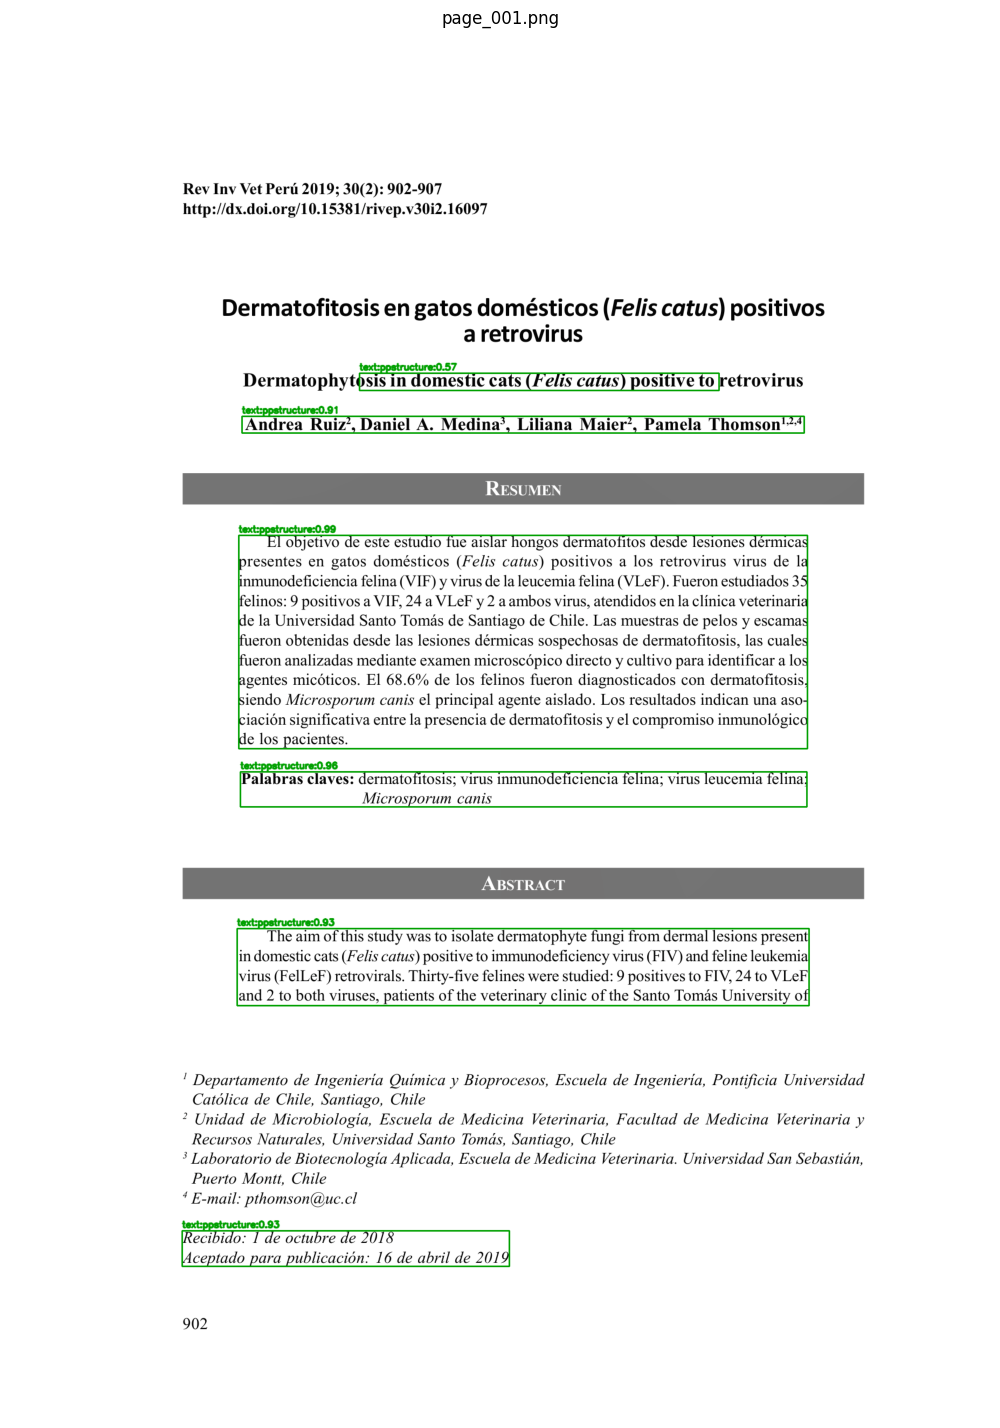

In [17]:

debug_files = sorted(OUT["debug_pages"].glob("*.png"))
if debug_files:
    img = cv2.imread(str(debug_files[0]))
    plt.figure(figsize=(14, 18))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(debug_files[0].name)
    plt.show()
else:
    print("No hay páginas de debug todavía.")

## Siguientes mejoras recomendadas

1. **Entrenar o afinar layout detection** con tu propio dataset si los papers tienen plantillas muy particulares.
2. Añadir **table structure recognition** con `microsoft/table-transformer-structure-recognition` para extraer filas y columnas dentro de cada tabla. Ese modelo está publicado por Microsoft en Hugging Face como complemento del detector de tablas. citeturn185353search2turn185353search4
3. Separar este notebook en módulos de `src/`:
   - `src/docvision/io.py`
   - `src/docvision/layout.py`
   - `src/docvision/tables.py`
   - `src/docvision/ocr.py`
   - `src/docvision/pipeline.py`
4. Convertir la celda `run_pipeline()` en un script CLI para procesar lotes de PDFs.